**Before you start: set up the environment**

---

This notebook expects the project's `uv`-managed virtual environment (named **`mlrcv-2026-exercise`**) as its kernel. If you have not set it up yet, do the following **once** from the root of the repository (the folder containing `pyproject.toml`):

1. **Install `uv`** (skip if already installed — check with `uv --version`):
   - Ubuntu / macOS: `curl -LsSf https://astral.sh/uv/install.sh | sh`
   - Windows (PowerShell): `powershell -ExecutionPolicy ByPass -c "irm https://astral.sh/uv/install.ps1 | iex"`

2. **Create the environment and install all dependencies:**
   ```bash
   uv sync
   ```
   This creates `.venv/` in the repo root and installs the exact versions pinned in `pyproject.toml` / `uv.lock`. Re-run `uv sync` whenever you pull new exercises.

3. **Activate the environment** (your prompt will show `(mlrcv-2026-exercise)`):
   - Ubuntu / macOS: `source .venv/bin/activate`
   - Windows (PowerShell): `.venv\Scripts\Activate.ps1`

4. **Select the kernel for this notebook:**
   - **VSCode:** click the kernel picker in the top-right of this notebook → *Python Environments…* → choose `.venv/bin/python` (labeled **`mlrcv-2026-exercise`**).
   - **JupyterLab:** run `jupyter lab` from the repo root (after activating the environment).

See the main [README](../README.md) for more details. If the first code cell below runs without import errors, you are all set.

**Exercise 1 - Data cleaning [10 pt]** 

---

This first exercise will be about data preparation and cleaning. In this exercise we will work with tabular data, work with some basic preprocessing and data cleaning operations.

**Note:** Implement the functions in `mlrcv/data_cleaning.py`—grading is based on that implementation. You may use this Jupyter notebook to run and test your code, but you do not need to change the notebook.

**1.1 Data preparation**

---

In [1]:
# import libraries used during this exercise
import pandas as pd
import numpy as np

In this exercise we will work with a meteorite landings data provided by NASA (available [here](https://www.kaggle.com/nasa/meteorite-landings)). This dataset contains information about the landing geodesic position, mass, type, class, year, etc. Please check the metadata file for more details.

In [2]:
# Dataset read
df = pd.read_csv("data/meteorite-landings.csv")
# show data
df

,name,id,nametype,recclass,mass,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775000, 6.083330)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.183330, 10.233330)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.216670, -113.000000)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.883330, -99.900000)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.166670, -64.950000)"
...,...,...,...,...,...,...,...,...,...,...
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037000, 17.018500)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.783330, 8.966670)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.250000, 17.666670)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.789170, 41.504600)"


Given this loaded dataframe, your first task will be to prepare this data:
- Remove not relevant columns (for example, 'id', 'name', 'GeoLocation')
- Convert all data to numerical
- Remove non-sense data (if any)


Please implement the following functions in the *data_cleaning.py* file:
- drop_column(df, col) [2 pt]
- remap_values(df, col, remap_dict) [1 pt]
- categorical_to_num(df, col) [1 pt]
- remove_row_outside_range(df, col, min_val, max_val) [2 pt]

Additionally, you need to complete the remapping dictionaries for the nametype and fall columns [1 pt]. 

In [3]:
# import the data_cleaning.py where you will need to implement the core functions
from mlrcv.data_cleaning import *


def data_preparation(df):
    #########################################################################
    # Implement your functions in data_cleaning.py then call them here
    ########################### Your data preparation #######################

    # drop not relevant columns
    df = drop_column(df, "id")
    df = drop_column(df, "name")
    df = drop_column(df, "GeoLocation")

    # fix typos for nametype and fall by using the remap dictionaries
    df = remap_values(df, "nametype", nametype_remap)
    df = remap_values(df, "fall", fall_remap)

    # convert type categorical strings to numerical data
    df = categorical_to_num(df, "nametype")
    df = categorical_to_num(df, "fall")
    df = categorical_to_num(df, "recclass")

    # remove rows with year outside the range
    df = remove_row_outside_range(df, "year", 860.0, 2016.0)

    #########################################################################
    return df


df = data_preparation(df)
df

,nametype,recclass,mass,fall,year,reclat,reclong
0,0,0,21.0,0,1880.0,50.77500,6.08333
1,0,1,720.0,0,1951.0,56.18333,10.23333
2,0,2,107000.0,0,1952.0,54.21667,-113.00000
3,0,3,1914.0,0,1976.0,16.88333,-99.90000
4,0,4,780.0,0,1902.0,-33.16667,-64.95000
...,...,...,...,...,...,...,...
45711,0,43,172.0,1,1990.0,29.03700,17.01850
45712,0,350,46.0,1,1999.0,13.78333,8.96667
45713,0,10,3.3,1,1939.0,49.25000,17.66667
45714,0,4,2167.0,1,2003.0,49.78917,41.50460


After your data cleaning you should notice many differences between the data before and after your data preparation, for example, less columns, different values. Besides that, the columns data type should be all numerical now (no object type).


**1.2 Data cleaning**

---

While preparing your data you should have noticed some undefined values (or *NaN*) in some fields. Before, they should only be ignored, now we need to handle this. In this second task you should deal with those *NaN* values.

Please implement the following functions in the *data_cleaning.py* file:
- replace_nan_with_mean_class(df, col, refcol) [2 pt]
- remove_nan_rows(df, col) [1 pt]

In [4]:
def data_cleaning(df):
    #########################################################################
    # Implement your functions in data_cleaning.py then call them here
    ########################### Your data cleaning ##########################
    for col in df.columns:
        # for mass, replace NaN with the mean mass of the corresponding recclass
        if col == "mass":
            df = replace_nan_with_mean_class(df, col, "recclass")

        # remove rows with NaN values for other columns
        df = remove_nan_rows(df, col)
    #########################################################################

    return df


df = data_cleaning(df)
display(df)
print("There are NaN values in the data: ", df.isnull().values.any())

,nametype,recclass,mass,fall,year,reclat,reclong
0,0,0,21.0,0,1880.0,50.77500,6.08333
1,0,1,720.0,0,1951.0,56.18333,10.23333
2,0,2,107000.0,0,1952.0,54.21667,-113.00000
3,0,3,1914.0,0,1976.0,16.88333,-99.90000
4,0,4,780.0,0,1902.0,-33.16667,-64.95000
...,...,...,...,...,...,...,...
45711,0,43,172.0,1,1990.0,29.03700,17.01850
45712,0,350,46.0,1,1999.0,13.78333,8.96667
45713,0,10,3.3,1,1939.0,49.25000,17.66667
45714,0,4,2167.0,1,2003.0,49.78917,41.50460


There are NaN values in the data:  False


If your implementations have worked the output from the code above should be **False** (this call check if the data frame has any NaN/null value).

**1.3 Visualization**

---

This section is **provided for visualization only**—students do **not** need to implement or modify anything here and this section is not graded.

The cell below plots the cleaned meteorite landings on a world map:
- Marker location: longitude/latitude
- Marker size: meteorite mass (log-scaled)

**Dependency**: the plot uses `cartopy`.

/Users/yagizalbayrak/Desktop/MSc-GE-2/Machine Learning/mlrcv-2026-exercise/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/yagizalbayrak/Desktop/MSc-GE-2/Machine Learning/mlrcv-2026-exercise/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_ocean.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/yagizalbayrak/Desktop/MSc-GE-2/Machine Learning/mlrcv-2026-exercise/.venv/lib/python3.13/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/Users/yagizalbayrak/Desktop/MSc-GE-2/Machine Learning/mlrcv-2026-exercise/.venv/lib/python3.13/site-packages/carto

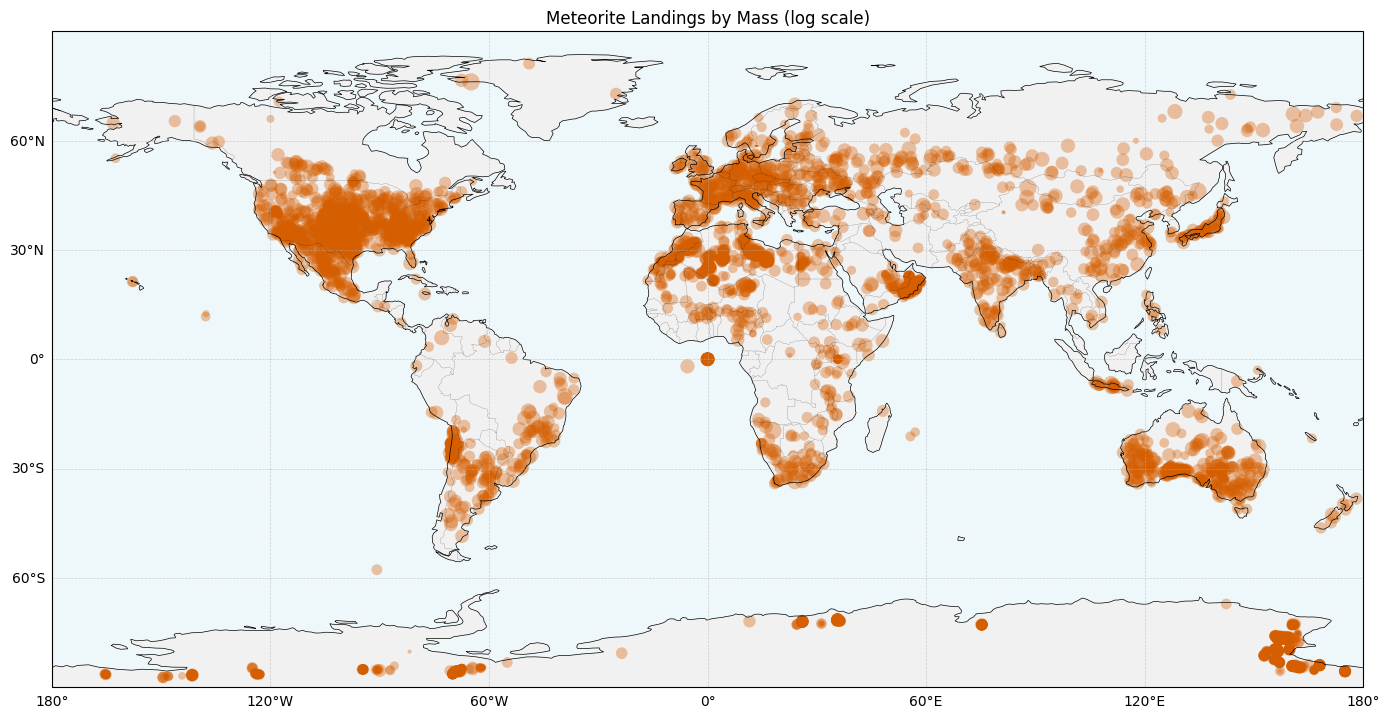

In [5]:
# Concise meteorite map (uses cleaned df)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": ccrs.PlateCarree()})
ax.add_feature(cfeature.LAND, facecolor="lightgray", alpha=0.3)
ax.add_feature(cfeature.OCEAN, facecolor="lightblue", alpha=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.2, alpha=0.5)
ax.set_global()
gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.6, linestyle="--")
gl.top_labels = gl.right_labels = False

# size of the marker is the log of the mass
sizes = np.clip(np.log10(df["mass"].values + 1) * 20, 1, 500)
ax.scatter(
    df["reclong"], df["reclat"], c="#D55E00", s=sizes, alpha=0.35, edgecolors="none", transform=ccrs.PlateCarree()
)
ax.set_title("Meteorite Landings by Mass (log scale)")
plt.tight_layout()
plt.show()

**Assignment Submission**

---

To submit your assignment, run the following command from the root of the repository:

```bash
sh submit.sh
```

**Check That You Actually Submitted**

You can check that your submission worked in several ways:

1. There is a new line in the file submission.txt with current date and time.
2. There is a new commit in your git history with the title "Submission".